In [ ]:
import os
import pandas as pd
import anndata as ad
import scanpy as sc
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import statsmodels.api as sm
from scipy.stats import (kruskal, mannwhitneyu, shapiro,
                         levene, spearmanr, chi2_contingency,
                         fisher_exact, wilcoxon, entropy)

from statsmodels.stats.multitest import multipletests
from statsmodels.stats.power import FTestAnovaPower
from itertools import combinations

AGE_GROUPS = ["0–3", "4–6", "7–10", "11–14", "15–18"]
METRICS    = ["Shannon", "prop_expanded", "Clonality", "n_clonotypes"]

import dandelion as ddl

In [6]:
adata_cd4 = sc.read_h5ad("/scratch/user/s4575250/BIOX7014_Thesis/write/05_TCR/PICA_Batch001-Batch007/PICA_Batch001-Batch007_cd4_combined_annot_with_age_scvi_tcr.h5ad")
adata_cd4.var_names_make_unique()
adata_cd4

AnnData object with n_obs × n_vars = 596486 × 38606
    obs: 'status', 'assignment', 'pica_id', 'pool_id', 'sequencing_batch', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'total_counts_hb', 'log1p_total_counts_hb', 'pct_counts_hb', 'status_manual', 'cell_type', 'broad_cell_type', 'pica_broad_cell_type', 'pica_cell_type', 'pica_cell_type_01_myeloid', 'pica_cell_type_02_b', 'pica_cell_type_03_nk_t', 'pica_cell_type_complete', 'pica_broad_cell_type_complete', 'pica_broad_cell_type_complete_01_gdT_corrected', 'pica_cell_type_complete_01_gdT_corrected', 'status_manual_01_pica', 'Record ID', 'Sex', 'Age_years', 'Age', 'Event Name', 'Was baseline blood sample collected?', 'IFC ID', "Child's sex", 'Age in 

### Load vdj object

In [7]:
vdj_cd4 = ddl.read_10x_vdj("/scratch/user/s4575250/BIOX7014_Thesis/data/PICA_Batch001-Batch007_tcr_merged/tcr_final/cd4",filename_prefix="filtered")
vdj_cd4

/scratch/user/s4575250/BIOX7014_Thesis/dandelion/src/dandelion/polars/core/_core.py:1995: PerformanceWarning: checking membership of a LazyFrame using `in` requires resolving its schema, which is a potentially expensive operation. Use `key in LazyFrame.collect_schema()` to check membership without this warning.


Lazy Dandelion object with n_obs = 571042 and n_contigs = 1119731
    data: cell_id, is_cell_10x, sequence_id, high_confidence_10x, sequence_length_10x, locus, v_call, d_call, j_call, c_call, complete_vdj, productive, fwr1_aa, fwr1, cdr1_aa, cdr1, fwr2_aa, fwr2, cdr2_aa, cdr2, fwr3_aa, fwr3, junction_aa, junction, fwr4_aa, fwr4, consensus_count, umi_count, clone_id, raw_consensus_id_10x, exact_subclonotype_id_10x, rearrangement_status
    metadata: cell_id, clone_id, clone_id_rank, locus_VDJ, locus_VJ, v_call_VDJ, v_call_VJ, d_call_VDJ, j_call_VDJ, j_call_VJ, c_call_VDJ, c_call_VJ, junction_aa_VDJ, junction_aa_VJ, junction_VDJ, junction_VJ, umi_count_VDJ, umi_count_VJ, locus_VDJ_main, locus_VJ_main, v_call_VDJ_main, v_call_VJ_main, d_call_VDJ_main, j_call_VDJ_main, j_call_VJ_main, c_call_VDJ_main, c_call_VJ_main, junction_aa_VDJ_main, junction_aa_VJ_main, junction_VDJ_main, junction_VJ_main, umi_count_VDJ_main, umi_count_VJ_main, locus_status, chain_status, rearrangement_status_VDJ, re

### restrict adata to match vdj object

In [8]:

vdj_ids_cd4 = (
    vdj_cd4.data
    .select("cell_id")
    .unique()
    .collect()
    .to_pandas()["cell_id"]
    .astype(str)
)

rna_ids_cd4 = adata_cd4.obs_names.astype(str)

matched = len(set(vdj_ids_cd4) & set(rna_ids_cd4))
only_in_rna = len(set(rna_ids_cd4) - set(vdj_ids_cd4))
only_in_vdj = len(set(vdj_ids_cd4) - set(rna_ids_cd4))

print("Matched:", matched)
print("Only in RNA:", only_in_rna)
print("Only in VDJ:", only_in_vdj)



Matched: 571042
Only in RNA: 25444
Only in VDJ: 0


In [9]:

mask = adata_cd4.obs_names.isin(vdj_ids_cd4)

obs_cols_keep = [
    "status",
    "assignment",
    "pica_id",
    "pool_id",
    "sequencing_batch",
    "Sex",
    "Age_years",
    "Batch",
    "Age_group",
    "cell_type",
    "pica_cell_type_complete_01_gdT_corrected",
    "leiden"
]

obs_cols_keep = [c for c in obs_cols_keep if c in adata_cd4.obs.columns]

adata_cd4_sub = ad.AnnData(
    obs=adata_cd4.obs.loc[mask, obs_cols_keep].copy()
)
adata_cd4_sub.obs_names = adata_cd4.obs_names[mask].copy()

if "X_umap" in adata_cd4.obsm:
    adata_cd4_sub.obsm["X_umap"] = adata_cd4.obsm["X_umap"][mask].copy()

if "X_scVI" in adata_cd4.obsm:
    adata_cd4_sub.obsm["X_scVI"] = adata_cd4.obsm["X_scVI"][mask].copy()

print(adata_cd4_sub)

AnnData object with n_obs × n_vars = 571042 × 0
    obs: 'status', 'assignment', 'pica_id', 'pool_id', 'sequencing_batch', 'Sex', 'Age_years', 'Batch', 'Age_group', 'cell_type', 'pica_cell_type_complete_01_gdT_corrected', 'leiden'
    obsm: 'X_umap', 'X_scVI'


In [10]:
# QC: Remove low quality contigs 
vdj_cd4, adata_cd4_sub = ddl.pp.check_contigs(
    vdj_cd4,
    adata=adata_cd4_sub,
    library_type="tr-ab"
)

print(vdj_cd4)
print(adata_cd4_sub)


Filtering contigs...
Marking ambiguous contigs...
Initializing DandelionPolars object...


/scratch/user/s4575250/BIOX7014_Thesis/dandelion/src/dandelion/polars/core/_core.py:1995: PerformanceWarning: checking membership of a LazyFrame using `in` requires resolving its schema, which is a potentially expensive operation. Use `key in LazyFrame.collect_schema()` to check membership without this warning.


Lazy Dandelion object with n_obs = 571042 and n_contigs = 1250829
    data: cell_id, is_cell_10x, sequence_id, high_confidence_10x, sequence_length_10x, locus, v_call, d_call, j_call, c_call, complete_vdj, productive, fwr1_aa, fwr1, cdr1_aa, cdr1, fwr2_aa, fwr2, cdr2_aa, cdr2, fwr3_aa, fwr3, junction_aa, junction, fwr4_aa, fwr4, consensus_count, umi_count, clone_id, raw_consensus_id_10x, exact_subclonotype_id_10x, rearrangement_status, extra, ambiguous
    metadata: cell_id, clone_id, clone_id_rank, locus_VDJ, locus_VJ, v_call_VDJ, v_call_VJ, d_call_VDJ, j_call_VDJ, j_call_VJ, c_call_VDJ, c_call_VJ, productive_VDJ, productive_VJ, junction_aa_VDJ, junction_aa_VJ, junction_VDJ, junction_VJ, umi_count_VDJ, umi_count_VJ, locus_VDJ_main, locus_VJ_main, v_call_VDJ_main, v_call_VJ_main, d_call_VDJ_main, j_call_VDJ_main, j_call_VJ_main, c_call_VDJ_main, c_call_VJ_main, productive_VDJ_main, productive_VJ_main, junction_aa_VDJ_main, junction_aa_VJ_main, junction_VDJ_main, junction_VJ_main, umi_c

In [11]:
# Compute clone sizes
ddl.tl.clone_size(vdj_cd4)
vdj_cd4

Lazy Dandelion object with n_obs = 571042 and n_contigs = 1250829
    data: cell_id, is_cell_10x, sequence_id, high_confidence_10x, sequence_length_10x, locus, v_call, d_call, j_call, c_call, complete_vdj, productive, fwr1_aa, fwr1, cdr1_aa, cdr1, fwr2_aa, fwr2, cdr2_aa, cdr2, fwr3_aa, fwr3, junction_aa, junction, fwr4_aa, fwr4, consensus_count, umi_count, clone_id, raw_consensus_id_10x, exact_subclonotype_id_10x, rearrangement_status, extra, ambiguous
    metadata: cell_id, clone_id, clone_id_rank, locus_VDJ, locus_VJ, v_call_VDJ, v_call_VJ, d_call_VDJ, j_call_VDJ, j_call_VJ, c_call_VDJ, c_call_VJ, productive_VDJ, productive_VJ, junction_aa_VDJ, junction_aa_VJ, junction_VDJ, junction_VJ, umi_count_VDJ, umi_count_VJ, locus_VDJ_main, locus_VJ_main, v_call_VDJ_main, v_call_VJ_main, d_call_VDJ_main, j_call_VDJ_main, j_call_VJ_main, c_call_VDJ_main, c_call_VJ_main, productive_VDJ_main, productive_VJ_main, junction_aa_VDJ_main, junction_aa_VJ_main, junction_VDJ_main, junction_VJ_main, umi_c

In [12]:
# compute expanded vs non-expanded clone size
ddl.tl.clone_size(vdj_cd4, max_size=2)

In [13]:
vdj_cd4._metadata.collect()["clone_id_size_max_2"].value_counts()

clone_id_size_max_2,count
str,u32
"""1""",2575
""">= 2""",568467


### Transfer VDJ information into Scanpy object

In [14]:
ddl.tl.transfer(adata_cd4_sub, vdj_cd4)
print([c for c in adata_cd4_sub.obs.columns if "clone" in c.lower() or "contig" in c.lower()])

['has_contig', 'clone_id', 'clone_id_rank', 'clone_id_size', 'clone_id_size_prop', 'clone_id_size_category', 'clone_id_size_max_2']


In [15]:
print(adata_cd4_sub.obs["clone_id_size_category"].astype(str).value_counts(dropna=False))
print(adata_cd4_sub.obs["clone_id_size"].value_counts(dropna=False).head(20))

clone_id_size_category
Rare     569266
Small      1776
Name: count, dtype: int64
clone_id_size
21    58758
22    57266
20    56720
19    50293
23    48047
18    42228
24    36360
17    30974
25    26950
16    25088
15    18600
26    18018
14    13594
13    11557
27    10368
12     8640
11     7337
10     6560
28     5964
9      5328
Name: count, dtype: int64


In [16]:
pd.crosstab(
    adata_cd4_sub.obs["clone_id_size_category"],
    adata_cd4_sub.obs["clone_id_size"]
)

clone_id_size,1,2,3,4,5,6,7,8,9,10,...,75,84,87,96,98,106,147,157,283,317
clone_id_size_category,,,,,,,,,,,,,,,,,,,,,
Rare,2575,1566,1380,1576,2125,2772,3766,5056,5328,6560,...,0,0,0,0,0,0,0,0,0,0
Small,0,0,0,0,0,0,0,0,0,0,...,75,84,87,96,98,106,147,157,283,317


<Axes: xlabel='clone_id_size', ylabel='Count'>

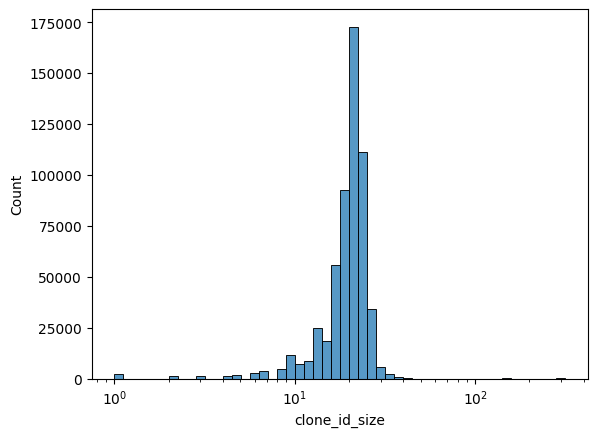

In [17]:
sns.histplot(
    adata_cd4_sub.obs["clone_id_size"],
    bins=50,
    log_scale=True
)

In [18]:
adata_cd4_sub

AnnData object with n_obs × n_vars = 571042 × 0
    obs: 'status', 'assignment', 'pica_id', 'pool_id', 'sequencing_batch', 'Sex', 'Age_years', 'Batch', 'Age_group', 'cell_type', 'pica_cell_type_complete_01_gdT_corrected', 'leiden', 'has_contig', 'clone_id', 'clone_id_rank', 'locus_VDJ', 'locus_VJ', 'v_call_VDJ', 'v_call_VJ', 'd_call_VDJ', 'j_call_VDJ', 'j_call_VJ', 'c_call_VDJ', 'c_call_VJ', 'productive_VDJ', 'productive_VJ', 'junction_aa_VDJ', 'junction_aa_VJ', 'junction_VDJ', 'junction_VJ', 'umi_count_VDJ', 'umi_count_VJ', 'locus_VDJ_main', 'locus_VJ_main', 'v_call_VDJ_main', 'v_call_VJ_main', 'd_call_VDJ_main', 'j_call_VDJ_main', 'j_call_VJ_main', 'c_call_VDJ_main', 'c_call_VJ_main', 'productive_VDJ_main', 'productive_VJ_main', 'junction_aa_VDJ_main', 'junction_aa_VJ_main', 'junction_VDJ_main', 'junction_VJ_main', 'umi_count_VDJ_main', 'umi_count_VJ_main', 'locus_status', 'chain_status', 'rearrangement_status_VDJ', 'rearrangement_status_VJ', 'clone_id_size', 'clone_id_size_prop', 'c

## Clone annotation

In [19]:
# Use existing clone size category already stored in the object

celltype_col = "pica_cell_type_complete_01_gdT_corrected"
clone_cat_col = "clone_id_size_category"

adata_tcr = adata_cd4_sub[
    adata_cd4_sub.obs["clone_id"].notna()
].copy()

print("TCR cells with clone_id:", adata_tcr.n_obs)
print("Unique clonotypes:", adata_tcr.obs["clone_id"].nunique())
print("Clone size category counts:")
print(adata_tcr.obs[clone_cat_col].value_counts(dropna=False))

TCR cells with clone_id: 571042
Unique clonotypes: 34921
Clone size category counts:
clone_id_size_category
Rare     569266
Small      1776
Name: count, dtype: int64


### Define expanded clones

In [20]:
# use Dandelion labels to make binary label
adata_tcr.obs["expanded_status"] = adata_tcr.obs["clone_id_size_max_2"].map({
    "1": "Non-expanded",
    ">= 2": "Expanded"
})

print(adata_tcr.obs["expanded_status"].value_counts(dropna=False))

expanded_status
Expanded        568467
Non-expanded      2575
Name: count, dtype: int64


In [21]:
print(adata_tcr)

AnnData object with n_obs × n_vars = 571042 × 0
    obs: 'status', 'assignment', 'pica_id', 'pool_id', 'sequencing_batch', 'Sex', 'Age_years', 'Batch', 'Age_group', 'cell_type', 'pica_cell_type_complete_01_gdT_corrected', 'leiden', 'has_contig', 'clone_id', 'clone_id_rank', 'locus_VDJ', 'locus_VJ', 'v_call_VDJ', 'v_call_VJ', 'd_call_VDJ', 'j_call_VDJ', 'j_call_VJ', 'c_call_VDJ', 'c_call_VJ', 'productive_VDJ', 'productive_VJ', 'junction_aa_VDJ', 'junction_aa_VJ', 'junction_VDJ', 'junction_VJ', 'umi_count_VDJ', 'umi_count_VJ', 'locus_VDJ_main', 'locus_VJ_main', 'v_call_VDJ_main', 'v_call_VJ_main', 'd_call_VDJ_main', 'j_call_VDJ_main', 'j_call_VJ_main', 'c_call_VDJ_main', 'c_call_VJ_main', 'productive_VDJ_main', 'productive_VJ_main', 'junction_aa_VDJ_main', 'junction_aa_VJ_main', 'junction_VDJ_main', 'junction_VJ_main', 'umi_count_VDJ_main', 'umi_count_VJ_main', 'locus_status', 'chain_status', 'rearrangement_status_VDJ', 'rearrangement_status_VJ', 'clone_id_size', 'clone_id_size_prop', 'c

In [22]:
age_bins = [0, 3, 6, 10, 14, 18]
age_labels = ["0–3", "4–6", "7–10", "11–14", "15–18"]

adata_tcr.obs["Age_group"] = pd.cut(
        adata_tcr.obs["Age_years"],
        bins= age_bins,
        labels= age_labels,
        right=False
    )

adata_tcr.obs["Age_group"] = adata_tcr.obs["Age_group"].cat.set_categories(age_labels)

In [23]:
pd.crosstab(
    adata_tcr.obs["clone_id_size_category"],
    adata_tcr.obs["expanded_status"]
)

expanded_status,Expanded,Non-expanded
clone_id_size_category,,
Rare,566691,2575
Small,1776,0


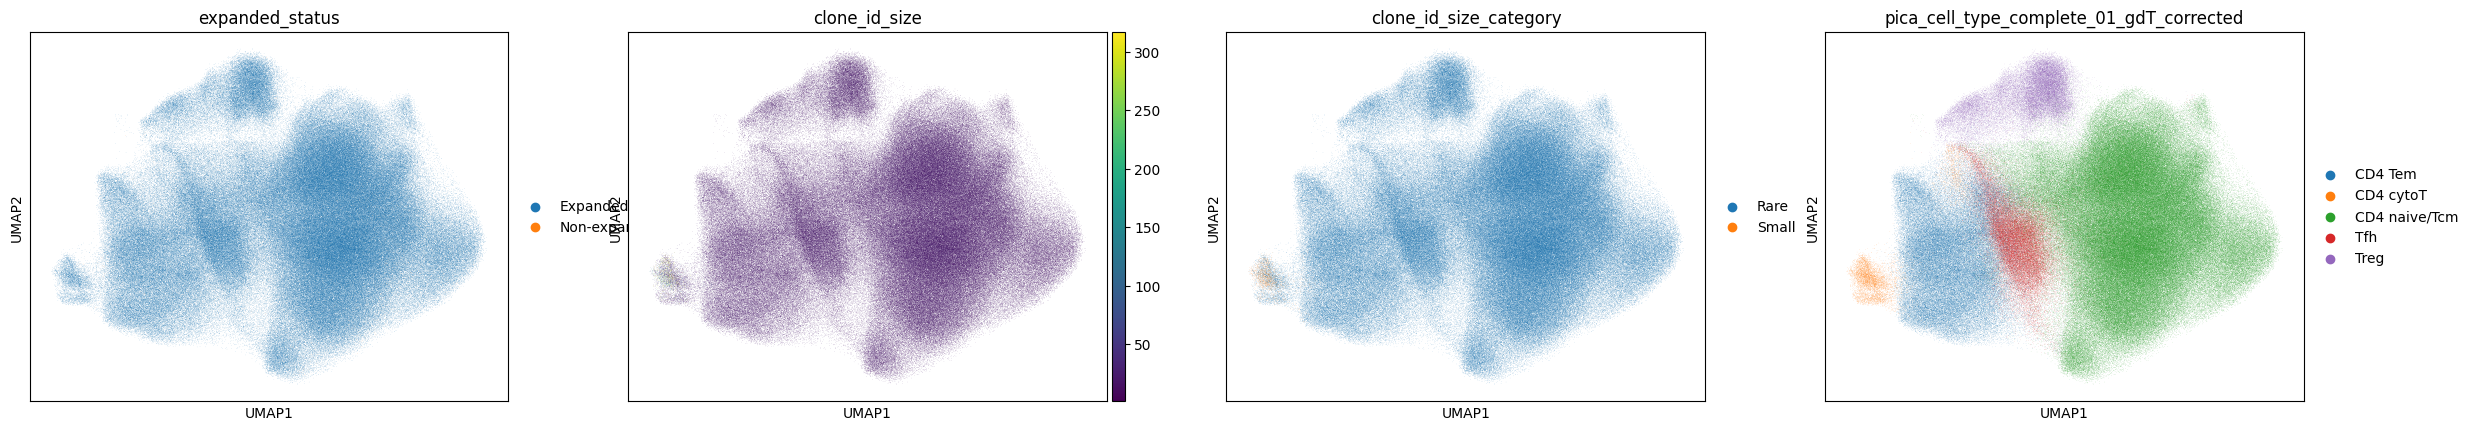

In [24]:
sc.pl.umap(
    adata_tcr,
    color=[
        "expanded_status",
        "clone_id_size",
        clone_cat_col,
        celltype_col,
    ],
    na_in_legend=False,
)

## visualization

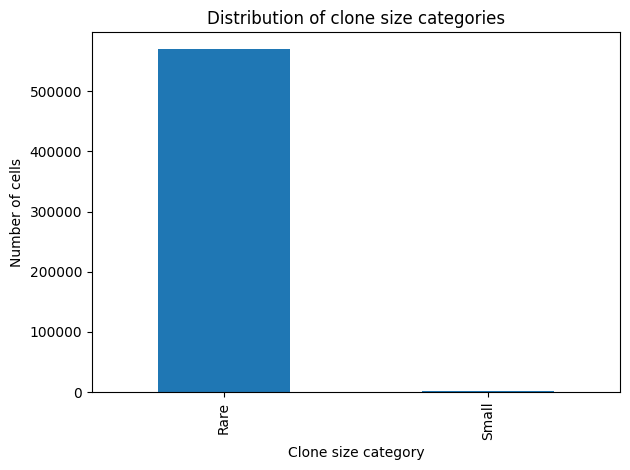

In [25]:
# Clone size distribution
clone_counts = (
    adata_tcr.obs[clone_cat_col]
    .value_counts(dropna=False)
)

clone_counts.plot(kind="bar")
plt.ylabel("Number of cells")
plt.xlabel("Clone size category")
plt.title("Distribution of clone size categories")
plt.tight_layout()
plt.show()

/scratch/user/s4575250/BIOX7014_Thesis/dandelion/src/dandelion/polars/plotting/_plotting.py:257: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.


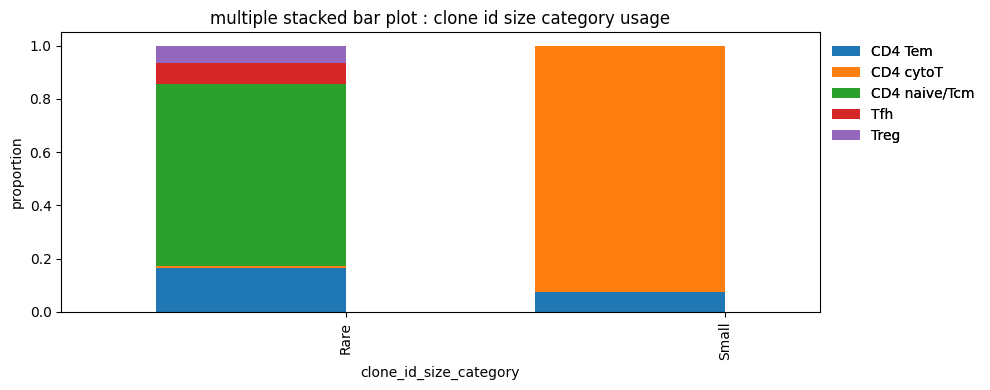

In [26]:
ddl.pl.stackedbarplot(
    adata_tcr,
    group_by=celltype_col,
    color=clone_cat_col,
    normalize=True,
    figsize=(10, 4),
)
plt.legend(bbox_to_anchor=(1, 1), loc="upper left", frameon=False)
plt.tight_layout()
plt.show()

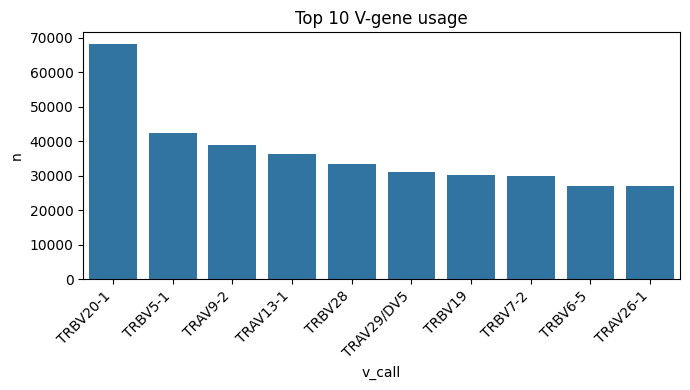

In [27]:
vdj_df = vdj_cd4.data.select(["cell_id", "v_call"]).collect().to_pandas()
vdj_df["cell_id"] = vdj_df["cell_id"].astype(str).str.replace("-1$", "", regex=True)

v_usage = (
    vdj_df.dropna(subset=["v_call"])
    .groupby("v_call")
    .size()
    .sort_values(ascending=False)
    .head(10)
    .reset_index(name="n")
)

plt.figure(figsize=(7, 4))
sns.barplot(data=v_usage, x="v_call", y="n")
plt.xticks(rotation=45, ha="right")
plt.title("Top 10 V-gene usage")
plt.tight_layout()
plt.show()

## Donor level diversity estimation
- Shannon diversity
- Simpson diversity
- Inverse diversity
- Clonality
- Richness

In [28]:
# create donor level summary
adata_tcr.obs["expanded_flag"] = (
    adata_tcr.obs["clone_id_size_category"]
    .map({"Rare": 0, "Small": 1})
    .astype(float)
)

def shannon_from_clone_ids(clone_ids):
    counts = clone_ids.value_counts()
    p = counts / counts.sum()
    return entropy(p)

def simpson_from_clone_ids(clone_ids):
    counts = clone_ids.value_counts()
    p = counts / counts.sum()
    return np.sum(p ** 2)

donor_summary = (
    adata_tcr.obs.dropna(subset=["pica_id"])
    .groupby("pica_id")
    .agg(
        n_tcr_cells=("clone_id", "size"),
        n_clonotypes=("clone_id", pd.Series.nunique),
        Age_years=("Age_years", "first"),
        Age_group=("Age_group", "first"),
        Sex=("Sex", "first"),
    )
)

# add Shannon / Simpson / Clonality / expanded proportion only on non-null clone_id
clone_nonnull = adata_tcr.obs.dropna(subset=["pica_id", "clone_id"]).copy()

shannon_by_donor = clone_nonnull.groupby("pica_id")["clone_id"].apply(shannon_from_clone_ids)
simpson_by_donor = clone_nonnull.groupby("pica_id")["clone_id"].apply(simpson_from_clone_ids)

donor_summary["Shannon"] = shannon_by_donor
donor_summary["Simpson"] = simpson_by_donor
donor_summary["Clonality"] = 1 - donor_summary["Simpson"]

prop_expanded = (
    adata_tcr.obs
    .groupby("pica_id")["expanded_flag"]
    .mean()
)

donor_summary["prop_expanded"] = prop_expanded


donor_summary = donor_summary.reset_index()
display(donor_summary.head())

/scratch/temp/24944012/ipykernel_2499219/1134017701.py:20: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
/scratch/temp/24944012/ipykernel_2499219/1134017701.py:33: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
/scratch/temp/24944012/ipykernel_2499219/1134017701.py:34: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
/scratch/temp/24944012/ipykernel_2499219/1134017701.py:42: FutureWarning: The default of observed=False is deprecat

,pica_id,n_tcr_cells,n_clonotypes,Age_years,Age_group,Sex,Shannon,Simpson,Clonality,prop_expanded
0,PICA0001,2317,2297,2.09,0–3,Male,7.729842,0.000455,0.999545,0.008200
1,PICA0002,971,967,15.09,15–18,Male,6.872616,0.001038,0.998962,0.000000
2,PICA0003,1144,1142,0.83,0–3,Male,7.039863,0.000877,0.999123,0.000000
3,PICA0008,7855,7635,9.70,7–10,Female,8.925543,0.000137,0.999863,0.000000
4,PICA0009,4451,4338,4.76,4–6,Female,8.357799,0.000249,0.999751,0.003595


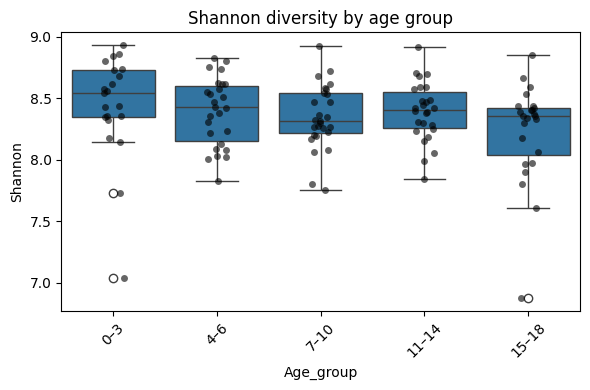

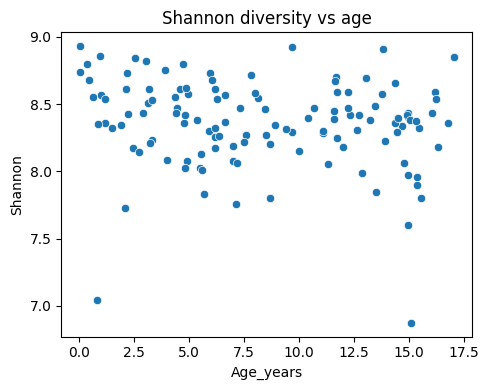

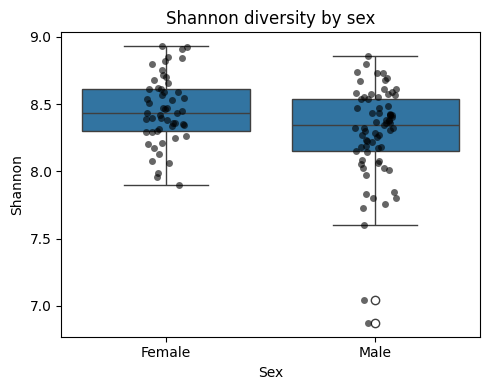

In [29]:
# shannon diversity
plt.figure(figsize=(6, 4))
sns.boxplot(data=donor_summary, x="Age_group", y="Shannon")
sns.stripplot(data=donor_summary, x="Age_group", y="Shannon", color="black", alpha=0.6)
plt.xticks(rotation=45)
plt.title("Shannon diversity by age group")
plt.tight_layout()
plt.show()

plt.figure(figsize=(5, 4))
sns.scatterplot(data=donor_summary, x="Age_years", y="Shannon")
plt.title("Shannon diversity vs age")
plt.tight_layout()
plt.show()

plt.figure(figsize=(5, 4))
sns.boxplot(data=donor_summary, x="Sex", y="Shannon")
sns.stripplot(data=donor_summary, x="Sex", y="Shannon", color="black", alpha=0.6)
plt.title("Shannon diversity by sex")
plt.tight_layout()
plt.show()

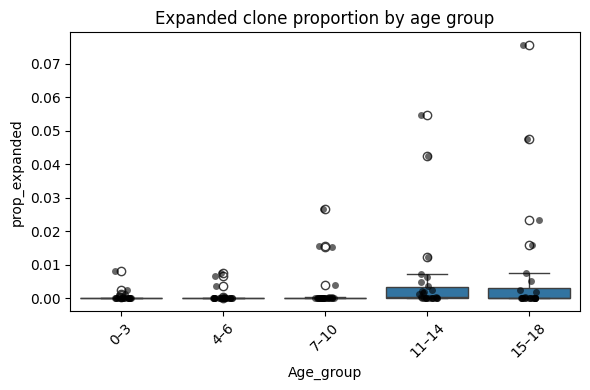

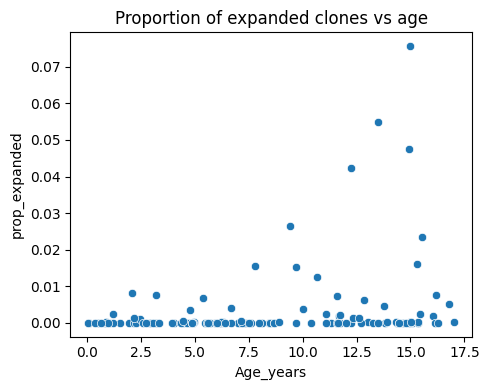

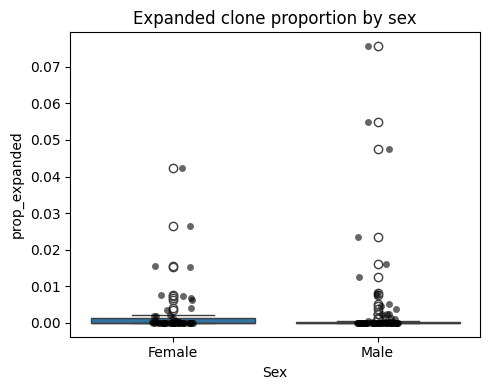

In [30]:
# expanded clone proportion
plt.figure(figsize=(6, 4))
sns.boxplot(data=donor_summary, x="Age_group", y="prop_expanded")
sns.stripplot(data=donor_summary, x="Age_group", y="prop_expanded", color="black", alpha=0.6)
plt.xticks(rotation=45)
plt.title("Expanded clone proportion by age group")
plt.tight_layout()
plt.show()

plt.figure(figsize=(5, 4))
sns.scatterplot(data=donor_summary, x="Age_years", y="prop_expanded")
plt.title("Proportion of expanded clones vs age")
plt.tight_layout()
plt.show()

plt.figure(figsize=(5, 4))
sns.boxplot(data=donor_summary, x="Sex", y="prop_expanded")
sns.stripplot(data=donor_summary, x="Sex", y="prop_expanded", color="black", alpha=0.6)
plt.title("Expanded clone proportion by sex")
plt.tight_layout()
plt.show()


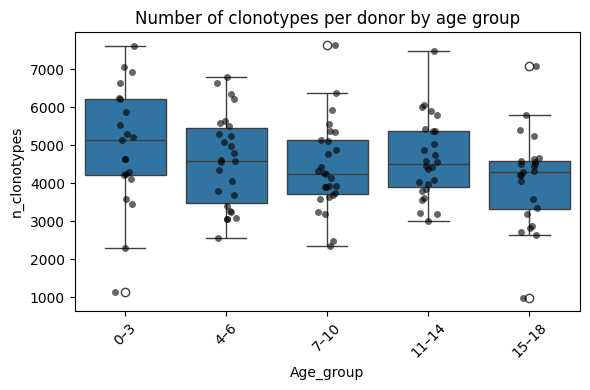

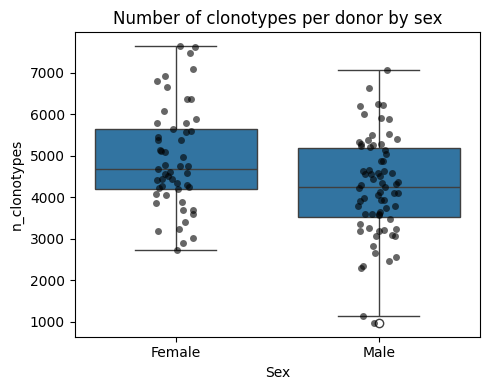

In [31]:
# clonotype richness
plt.figure(figsize=(6, 4))
sns.boxplot(data=donor_summary, x="Age_group", y="n_clonotypes")
sns.stripplot(data=donor_summary, x="Age_group", y="n_clonotypes", color="black", alpha=0.6)
plt.xticks(rotation=45)
plt.title("Number of clonotypes per donor by age group")
plt.tight_layout()
plt.show()

plt.figure(figsize=(5, 4))
sns.boxplot(data=donor_summary, x="Sex", y="n_clonotypes")
sns.stripplot(data=donor_summary, x="Sex", y="n_clonotypes", color="black", alpha=0.6)
plt.title("Number of clonotypes per donor by sex")
plt.tight_layout()
plt.show()

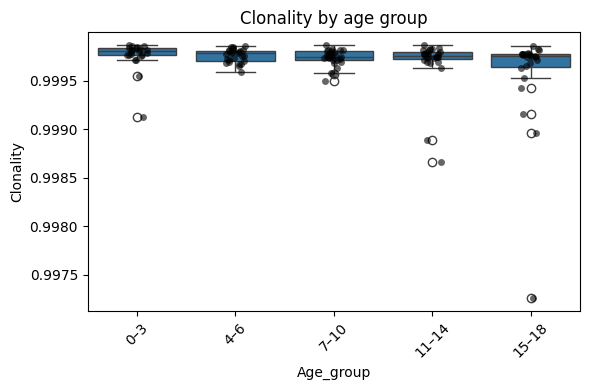

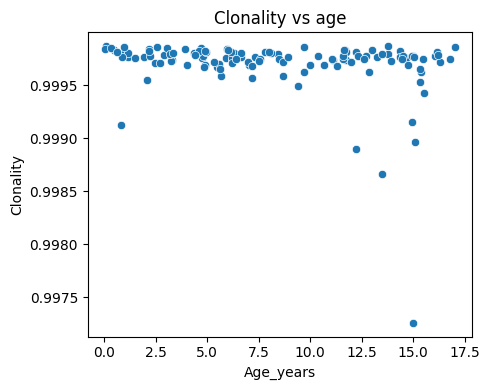

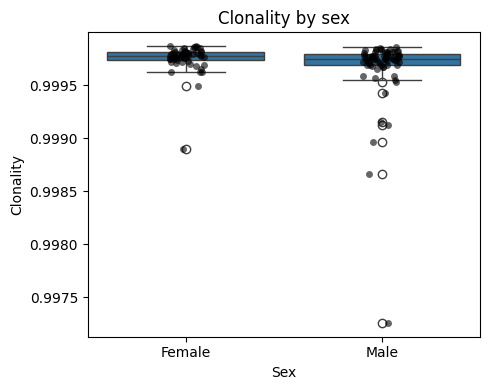

In [32]:
# clonality
plt.figure(figsize=(6, 4))
sns.boxplot(data=donor_summary, x="Age_group", y="Clonality")
sns.stripplot(data=donor_summary, x="Age_group", y="Clonality", color="black", alpha=0.6)
plt.xticks(rotation=45)
plt.title("Clonality by age group")
plt.tight_layout()
plt.show()

plt.figure(figsize=(5, 4))
sns.scatterplot(data=donor_summary, x="Age_years", y="Clonality")
plt.title("Clonality vs age")
plt.tight_layout()
plt.show()

plt.figure(figsize=(5, 4))
sns.boxplot(data=donor_summary, x="Sex", y="Clonality")
sns.stripplot(data=donor_summary, x="Sex", y="Clonality", color="black", alpha=0.6)
plt.title("Clonality by sex")
plt.tight_layout()
plt.show()

/scratch/temp/24944012/ipykernel_2499219/716115582.py:4: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
/scratch/temp/24944012/ipykernel_2499219/716115582.py:10: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.


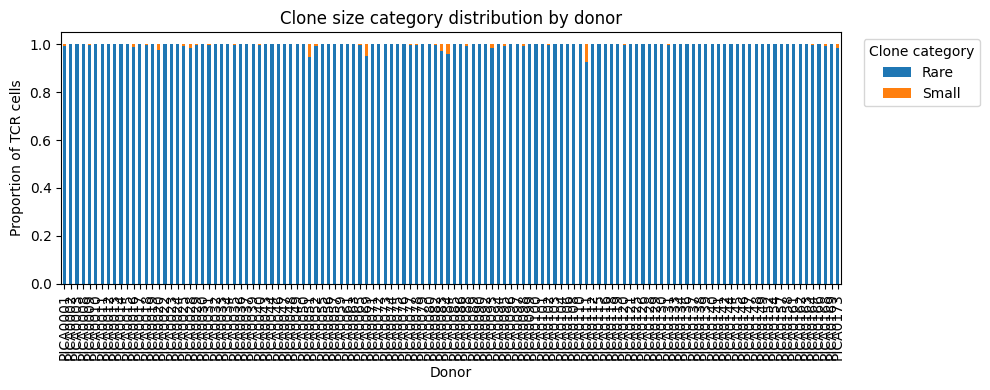

In [33]:
# clone size distribution
clone_dist = (
    adata_tcr.obs.dropna(subset=["pica_id", clone_cat_col])
    .groupby(["pica_id", clone_cat_col])
    .size()
    .rename("n_cells")
    .reset_index()
)

donor_totals = clone_dist.groupby("pica_id")["n_cells"].sum().rename("total_cells").reset_index()
clone_dist = clone_dist.merge(donor_totals, on="pica_id", how="left")
clone_dist["proportion"] = clone_dist["n_cells"] / clone_dist["total_cells"]

pivot_df = (
    clone_dist
    .pivot(index="pica_id", columns=clone_cat_col, values="proportion")
    .fillna(0)
)

clone_cols = [c for c in ["Rare", "Small"] if c in pivot_df.columns]
pivot_df = pivot_df[clone_cols]

pivot_df.plot(kind="bar", stacked=True, figsize=(10, 4))
plt.ylabel("Proportion of TCR cells")
plt.xlabel("Donor")
plt.title("Clone size category distribution by donor")
plt.xticks(rotation=90)
plt.legend(title="Clone category", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

/scratch/temp/24944012/ipykernel_2499219/1914076282.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.


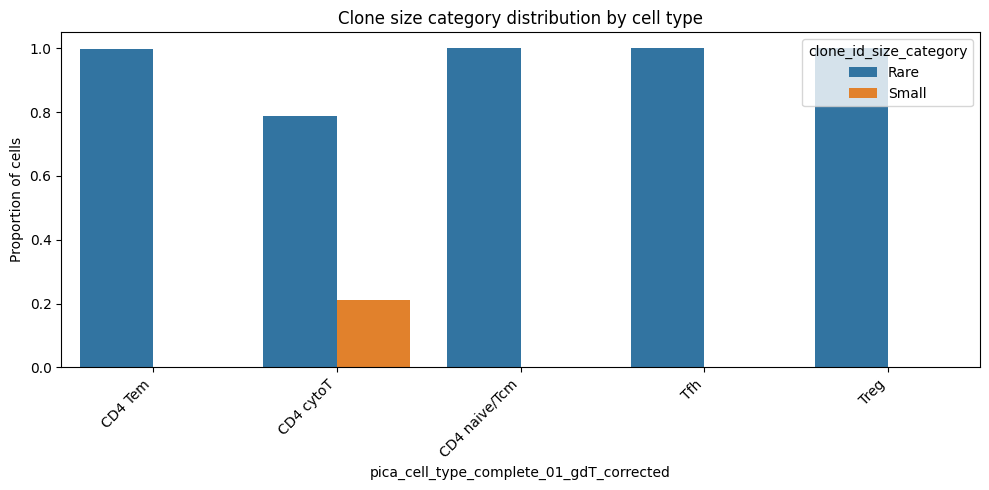

In [34]:
# cell type
clone_cat_prop = (
    adata_tcr.obs.groupby(celltype_col)[clone_cat_col]
    .value_counts(normalize=True)
    .rename("proportion")
    .reset_index()
)

plt.figure(figsize=(10, 5))
sns.barplot(
    data=clone_cat_prop,
    x=celltype_col,
    y="proportion",
    hue=clone_cat_col,
)
plt.xticks(rotation=45, ha="right")
plt.ylabel("Proportion of cells")
plt.xlabel(celltype_col)
plt.title("Clone size category distribution by cell type")
plt.tight_layout()
plt.show()

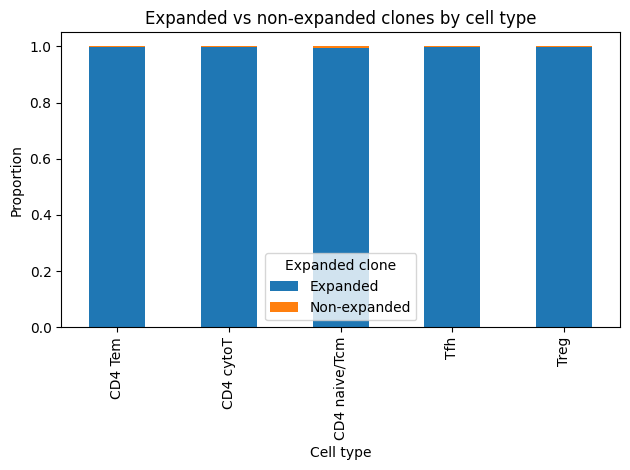

In [35]:
# Expanded clones by cell type
expanded_by_celltype = pd.crosstab(
    adata_tcr.obs[celltype_col],
    adata_tcr.obs["expanded_status"],
    normalize="index"
)

expanded_by_celltype.plot(kind="bar", stacked=True)
plt.ylabel("Proportion")
plt.xlabel("Cell type")
plt.title("Expanded vs non-expanded clones by cell type")
plt.legend(title="Expanded clone")
plt.tight_layout()
plt.show()

## Expanded clones visualisation

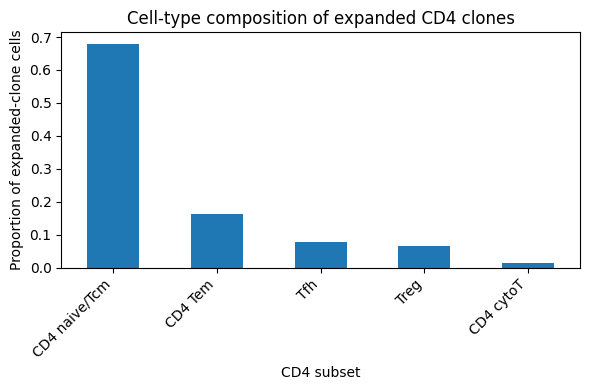

In [36]:
expanded_only = adata_tcr.obs[
    adata_tcr.obs["expanded_status"] == "Expanded"
]

expanded_celltype_prop = (
    expanded_only[celltype_col]
    .value_counts(normalize=True)
)

expanded_celltype_prop.plot(kind="bar", figsize=(6, 4))

plt.ylabel("Proportion of expanded-clone cells")
plt.xlabel("CD4 subset")
plt.title("Cell-type composition of expanded CD4 clones")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

/scratch/temp/24944012/ipykernel_2499219/229662910.py:9: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.


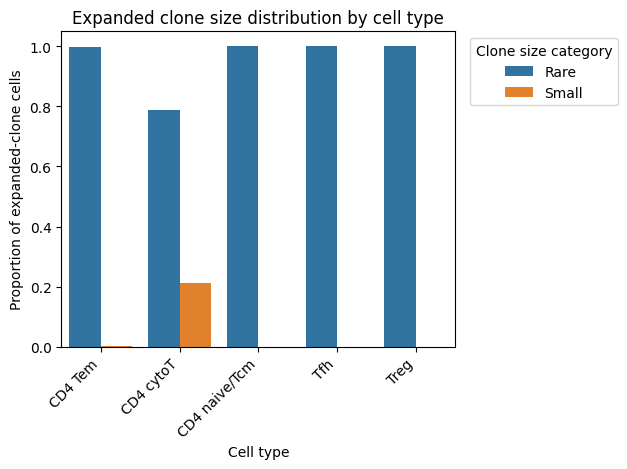

In [37]:
# cell type of expanded clones
clone_order = ["Rare", "Small"]
plot_df = adata_tcr.obs[
    adata_tcr.obs[clone_cat_col].isin(clone_order)
].copy()

clone_cat_prop = (
    plot_df
    .groupby(celltype_col)[clone_cat_col]
    .value_counts(normalize=True)
    .rename("proportion")
    .reset_index()
)

sns.barplot(
    data=clone_cat_prop,
    x=celltype_col,
    y="proportion",
    hue=clone_cat_col,
    hue_order=clone_order
)

plt.xticks(rotation=45, ha="right")
plt.ylabel("Proportion of expanded-clone cells")
plt.xlabel("Cell type")
plt.title("Expanded clone size distribution by cell type")
plt.legend(title="Clone size category", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

/scratch/temp/24944012/ipykernel_2499219/1739747199.py:9: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
/scratch/temp/24944012/ipykernel_2499219/1739747199.py:16: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.


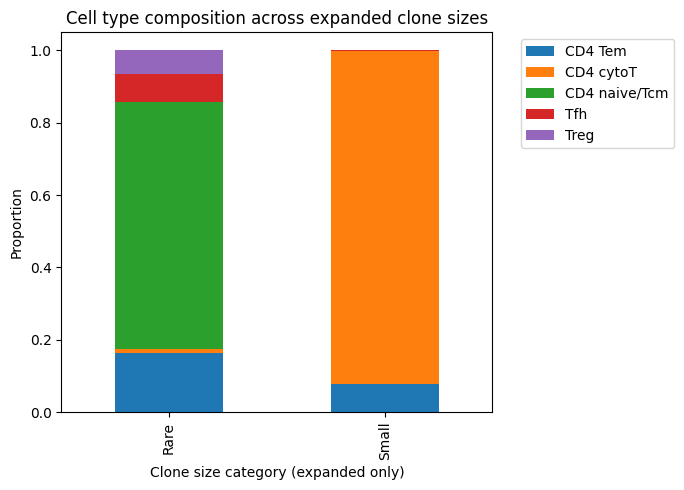

In [38]:
# keep only expanded clones
expanded_cells = adata_tcr.obs[
    adata_tcr.obs["expanded_status"] == "Expanded"
]

# compute proportions
comp = (
    expanded_cells
    .groupby([clone_cat_col, celltype_col])
    .size()
    .rename("n_cells")
    .reset_index()
)

# convert to proportions within each clone size category
comp["prop"] = comp.groupby(clone_cat_col)["n_cells"].transform(lambda x: x / x.sum())

# plot
pivot = comp.pivot(
    index=clone_cat_col,
    columns=celltype_col,
    values="prop"
).fillna(0)

pivot.plot(kind="bar", stacked=True, figsize=(7, 5))

plt.ylabel("Proportion")
plt.xlabel("Clone size category (expanded only)")
plt.title("Cell type composition across expanded clone sizes")
plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.show()

,Treg,CD4 cytoT,CD4 Tem,CD4 naive/Tcm,Tfh
Treg,1.000000,0.000040,0.000118,0.000020,0.000010
CD4 cytoT,0.000040,1.000000,0.001684,0.000016,0.000302
CD4 Tem,0.000118,0.001684,1.000000,0.000190,0.000653
CD4 naive/Tcm,0.000020,0.000016,0.000190,1.000000,0.000099
Tfh,0.000010,0.000302,0.000653,0.000099,1.000000


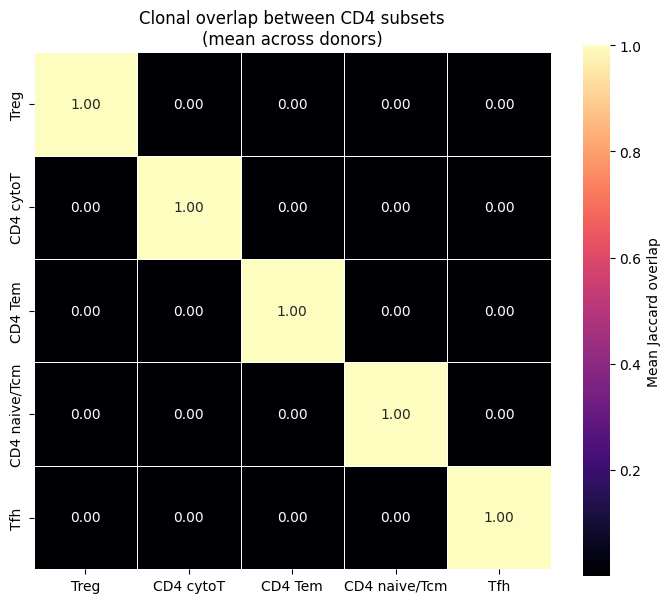

In [39]:
df_overlap = adata_tcr.obs[[celltype_col, "clone_id", "pica_id"]].copy()
df_overlap = df_overlap.dropna(subset=[celltype_col, "clone_id", "pica_id"])

preferred_order = ["Treg", "CD4 cytoT", "CD4 Tem", "CD4 naive/Tcm", "Tfh"]
celltypes = [ct for ct in preferred_order if ct in df_overlap[celltype_col].unique()]
remaining = sorted([ct for ct in df_overlap[celltype_col].unique() if ct not in celltypes])
celltypes = celltypes + remaining

donors = sorted(df_overlap["pica_id"].unique())

donor_mats = []
pairwise_records = []

for donor in donors:
    df_d = df_overlap[df_overlap["pica_id"] == donor].copy()

    clone_sets = {
        ct: set(df_d.loc[df_d[celltype_col] == ct, "clone_id"])
        for ct in celltypes
    }

    mat = pd.DataFrame(index=celltypes, columns=celltypes, dtype=float)

    for ct1 in celltypes:
        for ct2 in celltypes:
            s1 = clone_sets[ct1]
            s2 = clone_sets[ct2]
            inter = s1 & s2
            union = s1 | s2
            jaccard = len(inter) / len(union) if len(union) > 0 else np.nan
            mat.loc[ct1, ct2] = jaccard

            pairwise_records.append({
                "pica_id": donor,
                "celltype_1": ct1,
                "celltype_2": ct2,
                "n_shared_clones": len(inter),
                "n_union_clones": len(union),
                "jaccard_overlap": jaccard,
            })

    donor_mats.append(mat)

overlap_mean = pd.concat(donor_mats).groupby(level=0).mean()
overlap_mean = overlap_mean.loc[celltypes, celltypes]
overlap_long = pd.DataFrame(pairwise_records)

display(overlap_mean)

plt.figure(figsize=(7, 6))
sns.heatmap(
    overlap_mean,
    cmap="magma",
    annot=True,
    fmt=".2f",
    square=True,
    linewidths=0.5,
    cbar_kws={"label": "Mean Jaccard overlap"},
)
plt.title("Clonal overlap between CD4 subsets\n(mean across donors)")
plt.xlabel("")
plt.ylabel("")
plt.tight_layout()
plt.show()

## Statisical test
Uses ddl.tl.clone_diversity for diversity + bootstrapping, ddl.tl.clone_overlap for Jaccard,
and scipy/statsmodels only where Dandelion has no native helper.

Objects expected from your notebook: \
    vdj_cd4         — Dandelion object (after tl.transfer) \
    adata_tcr       — AnnData subset with clone_id not null \
    donor_summary   — donor-level DataFrame you built \
    celltype_col    — "pica_cell_type_complete_01_gdT_corrected" \
    clone_cat_col   — "clone_id_size_category" \
    AGE_GROUPS      — ["0–3","4–6","7–10","11–14","15–18"]


In [52]:
def kw_posthoc(df, value_col, group_col, groups, label=""):
    grp_data = [df.loc[df[group_col]==g, value_col].dropna().values
                for g in groups if (df[group_col]==g).sum() >= 2]
    h, p = kruskal(*grp_data)
    print(f"\n{'═'*55}\n  {label}")
    print(f"  Kruskal-Wallis  H={h:.4f}  p={p:.4f}  {'✓ sig' if p<0.05 else '✗ ns'}")

    pairs = list(combinations(groups, 2))
    raw_ps = []
    for g1, g2 in pairs:
        a = df.loc[df[group_col]==g1, value_col].dropna()
        b = df.loc[df[group_col]==g2, value_col].dropna()
        if len(a)>=2 and len(b)>=2:
            _, pm = mannwhitneyu(a, b, alternative="two-sided")
        else:
            pm = np.nan
        raw_ps.append(pm)

    valid = [(p_, g) for p_, g in zip(raw_ps, pairs) if not np.isnan(p_)]
    if valid:
        ps_v, gs_v = zip(*valid)
        _, p_adj, _, _ = multipletests(ps_v, method="fdr_bh")
        print("  Pairwise Mann-Whitney (BH-corrected):")
        for (g1, g2), pa in zip(gs_v, p_adj):
            print(f"    {g1:8s} vs {g2:8s}  p_fdr={pa:.4f} {'*' if pa<0.05 else ''}")

    n = sum(len(g) for g in grp_data)
    eta = (h - len(grp_data) + 1) / (n - len(grp_data))
    print(f"  η² = {eta:.4f}  ({'large' if eta>0.14 else 'medium' if eta>0.06 else 'small'})")


def cliff_delta(a, b):
    a, b = np.asarray(a), np.asarray(b)
    return (np.sum(a[:,None]>b[None,:]) - np.sum(a[:,None]<b[None,:])) / (len(a)*len(b))

In [66]:
# Assumption checks
for metric in METRICS:
    print(f"\n── Shapiro-Wilk normality: {metric} ──")
    for grp in AGE_GROUPS:
        sub = donor_summary.loc[donor_summary["Age_group"] == grp, metric].dropna()
        if len(sub) >= 3:
            stat, p = shapiro(sub)
            flag = "✓ normal" if p > 0.05 else "✗ non-normal"
            print(f"  {grp:8s}: W={stat:.3f}  p={p:.4f}  {flag}")

    print(f"\n── Levene variance equality: {metric} ──")
    grps = [donor_summary.loc[donor_summary["Age_group"] == g, metric].dropna().values
            for g in AGE_GROUPS if len(donor_summary.loc[donor_summary["Age_group"] == g, metric].dropna()) >= 2]
    if len(grps) >= 2:
        lev_stat, lev_p = levene(*grps)
        print(f"  Levene stat={lev_stat:.3f}  p={lev_p:.4f}  "
              f"{'✓ equal variances' if lev_p > 0.05 else '✗ unequal → use non-parametric'}")


── Shapiro-Wilk normality: Shannon ──
  0–3     : W=0.831  p=0.0020  ✗ non-normal
  4–6     : W=0.961  p=0.4068  ✓ normal
  7–10    : W=0.974  p=0.7039  ✓ normal
  11–14   : W=0.989  p=0.9931  ✓ normal
  15–18   : W=0.848  p=0.0020  ✗ non-normal

── Levene variance equality: Shannon ──
  Levene stat=0.775  p=0.5435  ✓ equal variances

── Shapiro-Wilk normality: prop_expanded ──
  0–3     : W=0.402  p=0.0000  ✗ non-normal
  4–6     : W=0.402  p=0.0000  ✗ non-normal
  7–10    : W=0.424  p=0.0000  ✗ non-normal
  11–14   : W=0.464  p=0.0000  ✗ non-normal
  15–18   : W=0.493  p=0.0000  ✗ non-normal

── Levene variance equality: prop_expanded ──
  Levene stat=2.063  p=0.0899  ✓ equal variances

── Shapiro-Wilk normality: Clonality ──
  0–3     : W=0.586  p=0.0000  ✗ non-normal
  4–6     : W=0.943  p=0.1589  ✓ normal
  7–10    : W=0.903  p=0.0159  ✗ non-normal
  11–14   : W=0.494  p=0.0000  ✗ non-normal
  15–18   : W=0.476  p=0.0000  ✗ non-normal

── Levene variance equality: Clonality ──
  

##### Statistical test on donor summary
(Kruskal-Wallis + posthoc, Spearman, sex)

In [ ]:
for metric in METRICS:
    kw_posthoc(donor_summary, metric, "Age_group", AGE_GROUPS, label=metric.upper())

print("\n── Spearman: metric ~ Age_years (continuous) ──")
for metric in METRICS:
    sub = donor_summary[["Age_years", metric]].dropna()
    r, p = spearmanr(sub["Age_years"], sub[metric])
    print(f"  {metric:20s}  r={r:.4f}  p={p:.4f}  {'✓' if p<0.05 else '✗'}")

print("\n── Sex differences (Mann-Whitney + Cliff's δ) ──")
sexes = donor_summary["Sex"].dropna().unique()
if len(sexes) == 2:
    s1, s2 = sexes
    for metric in METRICS:
        a = donor_summary.loc[donor_summary["Sex"]==s1, metric].dropna()
        b = donor_summary.loc[donor_summary["Sex"]==s2, metric].dropna()
        if len(a)>=2 and len(b)>=2:
            _, p = mannwhitneyu(a, b, alternative="two-sided")
            d   = cliff_delta(a, b)
            mag = "large" if abs(d)>0.47 else "medium" if abs(d)>0.33 else "small" if abs(d)>0.14 else "negligible"
            print(f"  {metric:20s}  p={p:.4f}  δ={d:.3f} ({mag})  {'✓' if p<0.05 else '✗'}")



═══════════════════════════════════════════════════════
  SHANNON
  Kruskal-Wallis  H=6.3521  p=0.1743  ✗ ns
  Pairwise Mann-Whitney (BH-corrected):
    0–3      vs 4–6       p_fdr=0.4508 
    0–3      vs 7–10      p_fdr=0.3371 
    0–3      vs 11–14     p_fdr=0.4508 
    0–3      vs 15–18     p_fdr=0.3340 
    4–6      vs 7–10      p_fdr=0.6308 
    4–6      vs 11–14     p_fdr=0.8908 
    4–6      vs 15–18     p_fdr=0.3566 
    7–10     vs 11–14     p_fdr=0.6271 
    7–10     vs 15–18     p_fdr=0.7765 
    11–14    vs 15–18     p_fdr=0.3566 
  η² = 0.0198  (small)

═══════════════════════════════════════════════════════
  PROP_EXPANDED
  Kruskal-Wallis  H=12.5538  p=0.0137  ✓ sig
  Pairwise Mann-Whitney (BH-corrected):
    0–3      vs 4–6       p_fdr=0.8122 
    0–3      vs 7–10      p_fdr=0.8122 
    0–3      vs 11–14     p_fdr=0.0760 
    0–3      vs 15–18     p_fdr=0.1093 
    4–6      vs 7–10      p_fdr=0.5294 
    4–6      vs 11–14     p_fdr=0.0568 
    4–6      vs 15–18     p_f

##### Clone size x Cell type 
Chi-square + Fisher

In [ ]:
contingency = pd.crosstab(
    adata_tcr.obs[celltype_col],
    adata_tcr.obs[clone_cat_col]
)
print("\nContingency table:")
print(contingency)

chi2, p_chi, dof, _ = chi2_contingency(contingency)
print(f"\nChi-square:  χ²={chi2:.4f}  df={dof}  p={p_chi:.4f}  {'✓ sig' if p_chi<0.05 else '✗ ns'}")

print("\n── Fisher's exact: each cell type vs. all others (BH) ──")
ct_list = contingency.index.tolist()
fisher_ps = []
for ct in ct_list:
    row_ct  = contingency.loc[ct].values
    row_oth = contingency.drop(ct).sum().values
    table   = np.array([row_ct, row_oth])
    if table.shape == (2, 2):
        _, fp = fisher_exact(table)
    else:
        fp = chi2_contingency(table)[1]
    fisher_ps.append((ct, fp))

_, p_adj_f, _, _ = multipletests([x[1] for x in fisher_ps], method="fdr_bh")
for (ct, _), pa in zip(fisher_ps, p_adj_f):
    print(f"  {ct:30s}  p_fdr={pa:.4f}  {'✓' if pa<0.05 else '✗'}")



Contingency table:
clone_id_size_category                      Rare  Small
pica_cell_type_complete_01_gdT_corrected               
CD4 Tem                                    93219    136
CD4 cytoT                                   6086   1636
CD4 naive/Tcm                             388637      3
Tfh                                        43735      1
Treg                                       37589      0

Chi-square:  χ²=110075.3989  df=4  p=0.0000  ✓ sig

── Fisher's exact: each cell type vs. all others (BH) ──
  CD4 Tem                         p_fdr=0.0000  ✓
  CD4 cytoT                       p_fdr=0.0000  ✓
  CD4 naive/Tcm                   p_fdr=0.0000  ✓
  Tfh                             p_fdr=0.0000  ✓
  Treg                            p_fdr=0.0000  ✓


##### Clone overlap

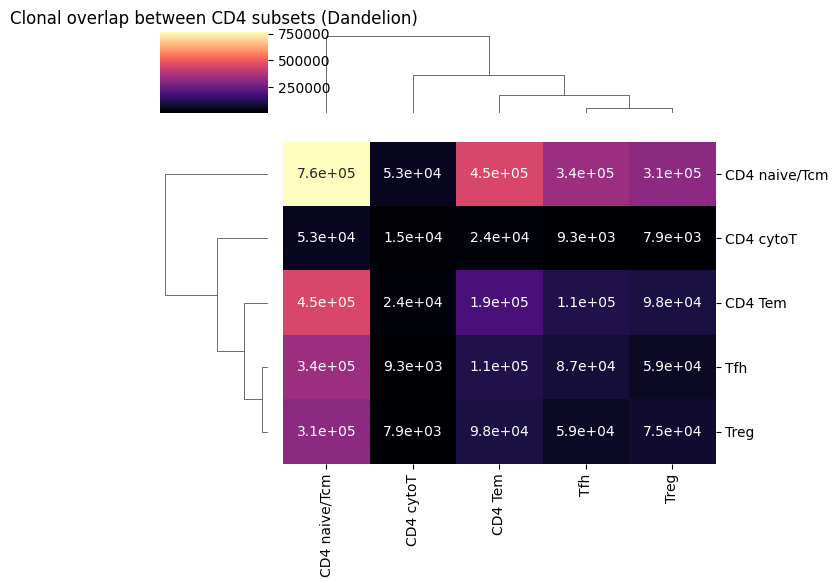

In [63]:
# ddl.tl.clone_overlap stores result in adata_tcr.uns
ddl.tl.clone_overlap(
    adata_tcr,
    celltype_col,      # positional
    weighted_overlap=True,
)
ddl.pl.clone_overlap(
    adata_tcr,
    celltype_col,      # positional
    weighted_overlap=True,
    as_heatmap=True,
    cmap="magma",
    annot=True,
    figsize=(7, 6),
)
plt.title("Clonal overlap between CD4 subsets (Dandelion)")
plt.tight_layout()
plt.show()


In [67]:
# Clonal overlap across cell types
# Test whether each cell-type pair has Jaccard > 0 across donors
# (one-sample Wilcoxon vs. zero)
from scipy.stats import wilcoxon

pair_results = []
for (ct1, ct2), sub in overlap_long[overlap_long["celltype_1"] < overlap_long["celltype_2"]].groupby(["celltype_1", "celltype_2"]):
    vals = sub["jaccard_overlap"].dropna()
    if len(vals) >= 5 and vals.sum() > 0:
        try:
            stat, p = wilcoxon(vals)
        except ValueError:
            p = np.nan
        pair_results.append({"pair": f"{ct1} | {ct2}", "median_J": vals.median(), "p_raw": p})

if pair_results:
    pair_df = pd.DataFrame(pair_results).dropna()
    _, pair_df["p_fdr"], _, _ = multipletests(pair_df["p_raw"], method="fdr_bh")
    pair_df["sig"] = pair_df["p_fdr"] < 0.05
    print("\nOne-sample Wilcoxon (Jaccard > 0), BH-corrected:")
    print(pair_df.sort_values("median_J", ascending=False).to_string(index=False))


One-sample Wilcoxon (Jaccard > 0), BH-corrected:
                     pair  median_J        p_raw        p_fdr   sig
      CD4 Tem | CD4 cytoT       0.0 1.110996e-11 1.110996e-10  True
  CD4 Tem | CD4 naive/Tcm       0.0 7.547498e-11 2.515833e-10  True
            CD4 Tem | Tfh       0.0 7.547498e-11 2.515833e-10  True
           CD4 Tem | Treg       0.0 9.815398e-04 1.963080e-03  True
CD4 cytoT | CD4 naive/Tcm       0.0 6.788915e-02 8.486144e-02 False
          CD4 cytoT | Tfh       0.0 3.345618e-03 5.576030e-03  True
         CD4 cytoT | Treg       0.0 1.797125e-01 1.996805e-01 False
      CD4 naive/Tcm | Tfh       0.0 1.174195e-06 2.935486e-06  True
     CD4 naive/Tcm | Treg       0.0 7.685794e-03 1.097971e-02  True
               Tfh | Treg       0.0 3.173105e-01 3.173105e-01 False


##### Power analysis

In [ ]:
n_per_group = donor_summary.groupby("Age_group").size()
print(f"\nN per age group:\n{n_per_group.to_string()}")
min_n = n_per_group.min()

pa = FTestAnovaPower()
print("\nRequired n per group for 80% power (α=0.05, k=5):")
for f, lbl in [(0.10,"small"),(0.25,"medium"),(0.40,"large")]:
    n_req = pa.solve_power(effect_size=f, alpha=0.05, power=0.8, k_groups=5)
    print(f"  f={f} ({lbl:6s}): need n≥{n_req:.1f}")

print(f"\nAchieved power with smallest group (n={min_n}):")
for f, lbl in [(0.10,"small"),(0.25,"medium"),(0.40,"large")]:
    pwr = pa.solve_power(effect_size=f, alpha=0.05, nobs=min_n, k_groups=5)
    print(f"  f={f} ({lbl:6s}): power={pwr:.3f}  {'✓' if pwr>=0.8 else '⚠ underpowered'}")


N per age group:
Age_group
0–3      21
4–6      26
7–10     27
11–14    26
15–18    24

Required n per group for 80% power (α=0.05, k=5):
  f=0.1 (small ): need n≥1198.3
  f=0.25 (medium): need n≥195.8
  f=0.4 (large ): need n≥79.5

Achieved power with smallest group (n=21):
  f=0.1 (small ): power=0.058  ⚠ underpowered
  f=0.25 (medium): power=0.105  ⚠ underpowered
  f=0.4 (large ): power=0.210  ⚠ underpowered


/scratch/temp/24944012/ipykernel_2499219/2153717225.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.


##### Summary

In [ ]:
rows = []
for metric in METRICS:
    grp_data = [donor_summary.loc[donor_summary["Age_group"]==g, metric].dropna().values
                for g in AGE_GROUPS if (donor_summary["Age_group"]==g).sum()>=2]
    h, p = kruskal(*grp_data)
    n = sum(len(g) for g in grp_data)
    eta = (h - len(grp_data) + 1) / (n - len(grp_data))
    rows.append({"Metric": metric, "Test": "Kruskal-Wallis",
                 "Stat": f"H={h:.3f}", "p": f"{p:.4f}",
                 "Sig": "✓" if p<0.05 else "✗", "η²": f"{eta:.4f}"})

rows.append({"Metric": "Clone size × cell type", "Test": "Chi-square",
             "Stat": f"χ²={chi2:.3f}", "p": f"{p_chi:.4f}",
             "Sig": "✓" if p_chi<0.05 else "✗", "η²": "—"})

print(pd.DataFrame(rows).to_string(index=False))

                Metric           Test          Stat      p Sig     η²
               Shannon Kruskal-Wallis       H=6.352 0.1743   ✗ 0.0198
         prop_expanded Kruskal-Wallis      H=12.554 0.0137   ✓ 0.0719
             Clonality Kruskal-Wallis       H=8.080 0.0887   ✗ 0.0343
          n_clonotypes Kruskal-Wallis       H=5.438 0.2452   ✗ 0.0121
Clone size × cell type     Chi-square χ²=110075.399 0.0000   ✓      —
